# 📊 Personal Finance Analysis

This project analyzes personal financial transactions to understand spending patterns, income behavior, and financial habits over time.

## 📁 Data Source

Dataset: Personal Finance Dataset (Kaggle)

The dataset contains individual financial transactions, including:
- Date
- Description
- Amount
- Transaction Type (credit/debit)
- Category
- Account Name

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

df = pd.read_csv("../data/raw/personal_transactions.csv")


In [126]:
df.shape
df.head()
df.dtypes
df.isna().sum()

Date                0
Description         0
Amount              0
Transaction Type    0
Category            0
Account Name        0
dtype: int64

## 🔍 Initial Observations

- The dataset contains no missing values.
- The "Date" column is initially stored as a string and needs conversion.
- The "Amount" column is already in numeric format.
- Categories appear to be well standardized.
- Transaction types are divided into "credit" and "debit".

In [127]:
df["date"] = pd.to_datetime(df["Date"])

## 🧠 Transaction Classification

To enable more accurate financial analysis, transactions were classified into:

- Income: real money entering the account (e.g., Paycheck)
- Expense: money leaving the account (debit transactions)
- Transfer: internal movements (e.g., Credit Card Payment)
- Other: any remaining credit transactions not classified above

In [128]:
conditions = [
    df["Category"] == "Credit Card Payment",
    df["Transaction Type"] == "debit",
    (df["Transaction Type"] == "credit") & (df["Category"] == "Paycheck")
]

choices = [
    "transfer",
    "expense",
    "income"
]

df["transaction_class"] = np.select(conditions, choices, default="other")

In [129]:
df["transaction_class"].value_counts()

transaction_class
expense     617
transfer    143
income       46
Name: count, dtype: int64

## 📆 Time Features

To analyze spending patterns over time, we extract temporal features such as year, month, and day of the week from the transaction date.


In [130]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.day_name()
df["year_month"] = df["date"].dt.to_period("M")

In [131]:
df.head()

,Date,Description,Amount,Transaction Type,Category,Account Name,date,transaction_class,year,month,day_of_week,year_month
0,01/01/2018,Amazon,11.11,debit,Shopping,Platinum Card,2018-01-01,expense,2018,1,Monday,2018-01
1,01/02/2018,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking,2018-01-02,expense,2018,1,Tuesday,2018-01
2,01/02/2018,Thai Restaurant,24.22,debit,Restaurants,Silver Card,2018-01-02,expense,2018,1,Tuesday,2018-01
3,01/03/2018,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card,2018-01-03,transfer,2018,1,Wednesday,2018-01
4,01/04/2018,Netflix,11.76,debit,Movies & DVDs,Platinum Card,2018-01-04,expense,2018,1,Thursday,2018-01


## 💸 Expenses by Category

In this section, we analyze how expenses are distributed across different categories to identify the main cost drivers.

In [132]:
df_expenses_category = (
    df[df["transaction_class"] == "expense"]
    .groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print(df_expenses_category)

                  Category    Amount
0          Mortgage & Rent  24754.50
1         Home Improvement  19092.87
2                Groceries   2795.21
3                Utilities   2776.00
4              Restaurants   2613.02
5                 Shopping   1973.24
6               Gas & Fuel   1715.17
7             Mobile Phone   1680.40
8                 Internet   1570.88
9           Auto Insurance   1350.00
10  Electronics & Software    719.00
11          Alcohol & Bars    539.13
12                 Haircut    378.00
13               Fast Food    330.63
14                   Music    224.49
15           Movies & DVDs    222.19
16            Coffee Shops    115.54
17              Television    104.78
18           Food & Dining     77.75
19           Entertainment      9.62


## 📊 Expense Distribution by Category

This chart shows how expenses are distributed across categories, helping identify the main cost drivers.

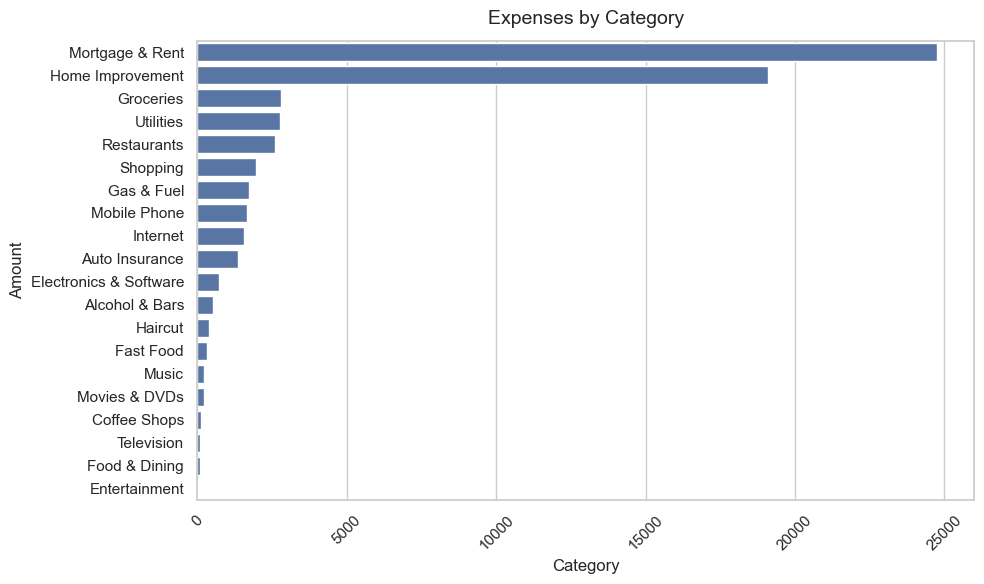

In [133]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_expenses_category,
    y="Category",
    x="Amount"
)

plt.title("Expenses by Category", fontsize=14, pad=12)
plt.xlabel("Category")
plt.ylabel("Amount")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../images/expenses_category.png", dpi=300, bbox_inches="tight")
plt.show()

In [134]:
df["transaction_class"].value_counts()

transaction_class
expense     617
transfer    143
income       46
Name: count, dtype: int64

### 🔍 Key Insights

- Housing costs (Mortgage & Rent) represent the largest share of expenses, indicating a high fixed cost structure in the budget.

- Home Improvement stands out as the second largest category, suggesting either a period of elevated spending (e.g., renovations) or potential seasonality. Further time-based analysis is needed to confirm whether this is recurring or sporadic.

- Essential living expenses such as Groceries, Utilities, and Restaurants show similar spending levels, indicating a relatively stable pattern in day-to-day consumption.

- There is a long tail of smaller expense categories, which individually have low impact but may represent a meaningful portion of total spending when combined.